In [1]:
import pandas as pd
# https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Checking if our graph is connected 

In [17]:
# only works if our txt is sorted by the first column
# which if it isn't then sorting it will fix it (tho that's another problem) but THIS specific data set seems to be sorted. Yay.

connected_subgarphs = [[0]] # First member added by hand
with open('Gowalla_edges.txt') as file:
    for line in file:

        line = line.rstrip()
        pair = tuple(map(int, line.split()))  # Read each line as a tuple st of couple numbers

        subgraph_pos = 0 
        for subgraph_i in connected_subgarphs:

            if (pair[0] in subgraph_i) and (pair[1]  in subgraph_i): # If both are in no need to do any
                break

            if (pair[0] in subgraph_i) and (pair[1] not in subgraph_i): # add node to subgraph as it is reachable
                subgraph_i.append(pair[1])
                break

            if (pair[1] in subgraph_i) and (pair[0] not in subgraph_i): # add node to subgraph as it is reachable
                subgraph_i.append(pair[0])
                break
        
            subgraph_pos += 1

        if subgraph_pos+1 > len(connected_subgarphs):      # Only case if both nodes are not in any of the subgraphs thus not reachable 
            connected_subgarphs.append([pair[0], pair[1]]) # Make a new subgaph


print(len(connected_subgarphs))

1


So not so interestingly we see that we do have a fully connected graph. Further graph exploration will be attempted later.

# Clustering

The main part of this clustering is to find out what points fall under the same sensible "activity hub" and if we can see anything intersting. Later on it will be interesting to see if the same people belonging to specific sets of actvity clusters are also part of the same community in the graph data. Lastly as a consequence of grouping things into hubs we will be able to find outliers (noise) which will be places that have very few other locations around them.

## Clustring DBscan for activity hubs

The motivation for choosing DBscan is:
1) We do not need to choose cluster number a priori for which DBscan works
2) We don't need to specify the cluster shape.
3) Handle differnece in distributions. Here DBscan might fail.

In [2]:
df = pd.read_csv('Gowalla_totalCheckins.txt', sep='\t', header=None, names=['user', 'check-in time', 'latitude', 'longitude', 'location_id'])
df.head()

,user,check-in time,latitude,longitude,location_id
0,0,2010-10-19T23:55:27Z,30.235909,-97.795140,22847
1,0,2010-10-18T22:17:43Z,30.269103,-97.749395,420315
2,0,2010-10-17T23:42:03Z,30.255731,-97.763386,316637
3,0,2010-10-17T19:26:05Z,30.263418,-97.757597,16516
4,0,2010-10-16T18:50:42Z,30.274292,-97.740523,5535878


In [3]:
original_len =len(df)
print(original_len, "number of entries")

6442892 number of entries


As seen from the map (ADRIAN) there as some coordinates that don't make sense. Thus we need to remove those that go out of latitude and longitude bounds

In [4]:
# Remove out of bound coordinates
df= df[(abs(df["longitude"]) <= 180) & (abs(df["latitude"]) <= 90)]
print(original_len - len(df), "points removed")

29 points removed


Now we still end up with a lot of data points (More than I can handle). We will split the world into two - Left (Americas) and right (Everything else). We eyeball the split at longitude = -30 which is around the middle of the atlantic ocean. As mentioned before  needs to be verified i.e. check if we are not accidentally splitting a potential cluster into two. This can be seen by simply looking at the map - no points in the middle or very near the split.

In [5]:
# Split the world into 2
df_left  = df[df["longitude"] < -30]  
df_right = df[df["longitude"] >= -30] 

print(len(df_left), "on the left")
print(len(df_right), "on the right")

3816660 on the left
2626203 on the right


In [6]:
# Merge same locations by ID
df_left_unique_id = df_left.drop_duplicates(subset=["location_id"])
df_right_unique_id = df_right.drop_duplicates(subset=["location_id"])

del df_left
del df_right
 
print(len(df_left_unique_id), " on the left")
print(len(df_right_unique_id), " on the right")

# And we know that we should get the same as num of unique ID before the split 
# Else the same ID is used on the left and right side of the worldd
print(len(df.drop_duplicates(subset=["location_id"])) - len(df_right_unique_id) - len(df_left_unique_id), " the differnece between origina and splits num of unique ID")

712101  on the left
568855  on the right
0  the differnece between origina and splits num of unique ID


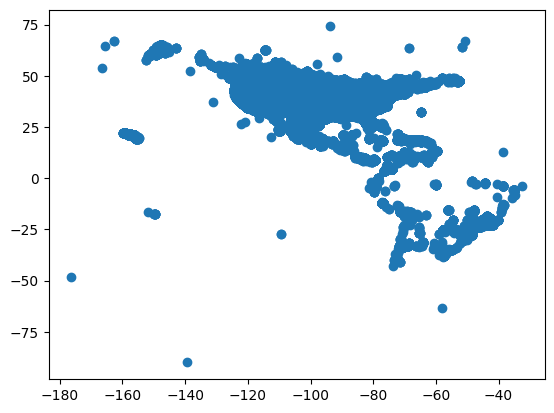

In [ ]:
# Map of the left side
plt.scatter(df_left_unique_id["longitude"], df_left_unique_id["latitude"], )

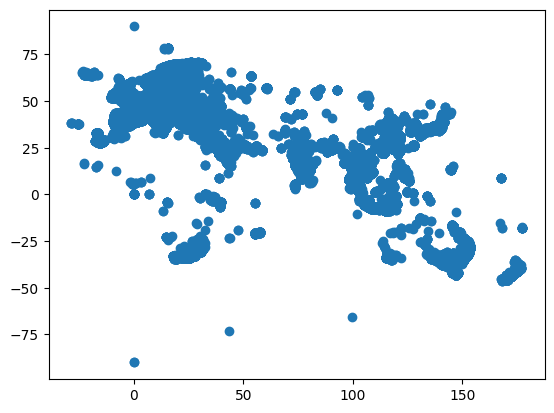

In [ ]:
# Map of the right side
plt.scatter(df_right_unique_id["longitude"], df_right_unique_id["latitude"], )

Now the two main problem are 
- how to handle the still large amount of points
- what epsilon to choose

The min_samples for core point is chosen as dimension * 2 - 1 = 3. Choosing any higher makes little sense as choosing too high will make small hubs be marked as noise. 

As seen above even after splitting the world in two we still too many points to be able to run the method especially as epsilon increases. We propose a following work around:

1. Cut up the space into (at least) espilon-overlapping regions.
2. Run DBSCAN for each region
3. If we have a core point in the border region it gives connection between the two regions.

If the overlap was smaller than epsilon we might loose out on points that make a point in our non-overallping reagion into a core point, thus we would loose the nice way to join border clusters. If it were bigger in theory we would not gain any extra information but in code we might not loose points due to rounding errors.

For a choice of epsilon the elbow method is attempted. We know that one degree change is approximately (decreaes the further from equator we go) 111km change in distance - this only gives a rough understanding on the scale of epsilon. As here we are trying to find the main hubs we should avoid picking small epsilon as it might produce a lot tiny clusters. Yet if we pick larger eps, for example even epsilon = 2, as metioned before we face a memory problem as we have a lot of dense areas (for each neighborhood we have to check a large amount of points) and we will only have big, non infromative clusters. 

Potential TODO Later on we will do clustering with two distance functions: Euclidean and Haversine, which is the distance is the angular distance between two points on the surface of a sphere.

# Elbow method. K-nearest Neighbors

Text(0, 0.5, '3rd Nearest Neighbor Distance')

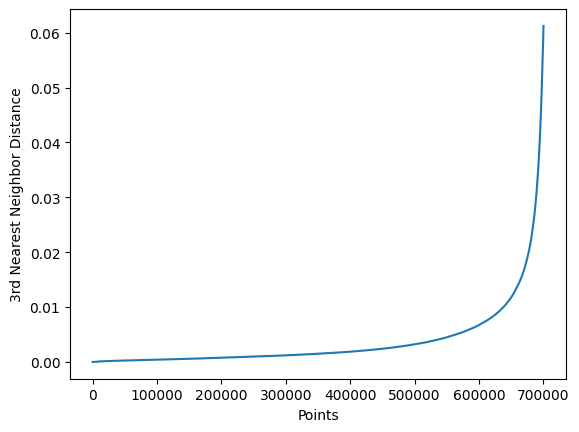

In [7]:
# elbow method in euclidean. 
temp_data = df_left_unique_id[["latitude", "longitude"]]
nbrs = NearestNeighbors(n_neighbors=3+1, metric="euclidean").fit(temp_data)
distances, indices = nbrs.kneighbors(temp_data)
distances = np.sort(distances[:, 3])
plt.plot(distances[0:700000]) # As plotting all points is not informative due to some points being very far away from anothers
plt.xlabel('Points')
plt.ylabel('3rd Nearest Neighbor Distance')

Text(0, 0.5, '3rd Nearest Neighbor Distance')

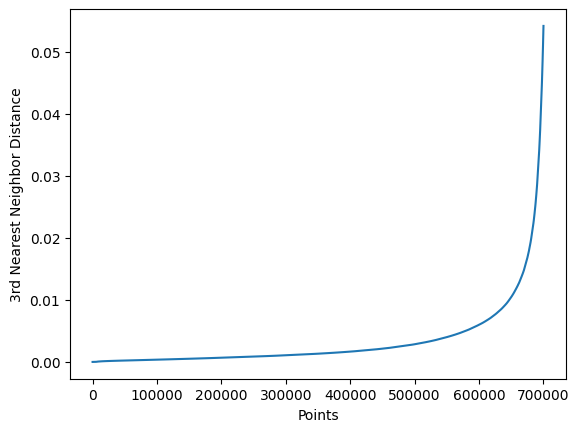

In [8]:
# elbow method In Haversine. The distance is more correct than using euclidean due to the data being on a spehere.
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.haversine_distances.html

df_left_unique_id['latitude_rad'] = np.radians(df['latitude'])
df_left_unique_id['longitude_rad'] = np.radians(df['longitude'])

temp_data = df_left_unique_id[["latitude_rad", "longitude_rad"]]
nbrs = NearestNeighbors(n_neighbors=3+1, metric="haversine").fit(temp_data) # n = itself + n-1 next neighbors
distances, indices = nbrs.kneighbors(temp_data)
distances = np.sort(distances[:, 3])
plt.plot(np.degrees(distances[0:700000])) # Back into degrees
plt.xlabel('Points')
plt.ylabel('3rd Nearest Neighbor Distance')

And here we see that most points are densly packed. The graphs suggests to pick epsilon around 0.01.

Another question that worthy thinking of is if Haversine is really needed here or can we accept the innacuracy of using Euclidean especially as we are not working on the whole world but only parts of it at a single time. For now we cluster with just euclidean metric.

https://codesignal.com/learn/courses/density-based-clustering-simplified/lessons/exploring-dbscan-clustering-with-python-and-scikit-learn
https://www.geeksforgeeks.org/machine-learning/dbscan-clustering-in-ml-density-based-clustering/

# Left world clustering 

In [ ]:
# We split the area into two with chosen epsilon
epsilon_elbow = 0.01

# Splitting the left side into two manageable reagions. The -90 was chosen by looking at the map and trying to split it to be around 50/50
df_left_left = df_left_unique_id[df_left_unique_id["longitude"] <= -90 + epsilon_elbow][["latitude", "longitude"]] 
df_left_right = df_left_unique_id[df_left_unique_id["longitude"] >= -90 - epsilon_elbow][["latitude", "longitude"]] 

# Here we notice that overlapping region is 2*epsilon. For now we accpet it.
# For very dense regions it might be problematic.
print(len(df_left_left), "points in left region")
print(len(df_left_right), "points in right region")

379059 points in left region
333336 points in right region


In [11]:
# Defining a clustring function. We only need lables and core points.

def DBSCAN_clusterin(clustering_data, epsilon, min_points = 3, metric = "euclidean"):
    clustering= DBSCAN(eps=epsilon, min_samples=min_points, metric=metric).fit(clustering_data)

    # We get this amount of clusters - noise
    print(len(set(clustering.labels_)) - (1 if -1 in clustering.labels_ else 0), "clusters not incl noise")
    print(np.sum(clustering.labels_ == -1), "points of noise")
    print((np.sum(clustering.labels_ == -1)/len(clustering_data)*100).round(2), "% of data is noise")

    labels = clustering.labels_
    cores_points = clustering.core_sample_indices_

    del clustering
    return labels , cores_points


In [33]:
labels, core_samples = DBSCAN_clusterin(df_left_left[["latitude", "longitude"]], epsilon_elbow)

5990 clusters not incl noise
20432 points of noise
5.39 % of data is noise


In [34]:
labels, core_samples = DBSCAN_clusterin(df_left_right[["latitude", "longitude"]], epsilon_elbow)

8844 clusters not incl noise
27690 points of noise
8.31 % of data is noise


Even without proper merging of the two overlapping regions into one we can see that for epsilon = 0.01 we get a massive amount of clusters. That is to be expceted as with the elbow method we are seeing what distance works for most points to be a core point and the "elbow" can be interpreted as points that are further away than most i.e. noise but we already knew our points are dense so at best this epsilon gives very local hubs and the result is interpretable.

Thus let's try increasing epsilon to 0.3 and then to 1 to see if the clusters become sensible.

In [9]:
# We split the area into two with chosen epsilon
epsilon = 0.3 

# Splitting the left side into two manageable reagions. The -90 was chosen by looking at the map and trying to split it to be around 50/50
df_left_left = df_left_unique_id[df_left_unique_id["longitude"] <= -93 + epsilon][["latitude", "longitude"]] 
df_left_right = df_left_unique_id[df_left_unique_id["longitude"] >= -93 - epsilon][["latitude", "longitude"]] 

# Here we notice that overlapping region is 2*epsilon. But that is fine because as the goal was to reduce points to sub 400000.

print(len(df_left_left), "points in left region")
print(len(df_left_right), "points in right region")

359304 points in left region
361542 points in right region


In [12]:
labels_left, core_samples_left = DBSCAN_clusterin(df_left_left[["latitude", "longitude"]], epsilon)

403 clusters not incl noise
392 points of noise
0.11 % of data is noise


In [13]:
labels_right, core_samples_right = DBSCAN_clusterin(df_left_right[["latitude", "longitude"]], epsilon)

241 clusters not incl noise
285 points of noise
0.08 % of data is noise


Once again - too many clusters. Yet let's merge these two regions and create noise point scatterplot.
The idea on how to merge these two regions is for a point that is in a left region cluster and in a right region cluster we hold that these two cluster are the same if x is a core point in at least one of the clusters. Notice that in this way multiple left - right region clusters could be joined into one i.e. 1 to 1 mapping is not guaranteed.

In [16]:
# Function that creates the mapping
def create_mapping(left_data, left_label, left_core, right_data, right_label, right_core, push = 0):
    # We find which points the splits share
    shared_points = left_data.index.intersection(right_data.index) 
    print(len(shared_points), " num of shared points")

    if push == 0: # Defualt value for push variable.
        push = len(set(left_label))


    # Nudge the labeling so that labess would be unique
    unique_labels_right = np.where(
        right_label == -1, 
        -1, 
        right_label + push # the nudge
    )

    # For every point we check if it is core in one of the splits
    # If it is core then we find how to map clusters. 
    # Although won't necessarily get 1 to 1 mapping so the relabeling part is not trivial

    mappings = []

    for i in shared_points:

        # We need this because our index in the dataframe don't match up with index we get via DBSCAN
        # Here even if two differnet locations share the same postion it does not matter.
        
        position_left = left_data.index.get_loc(i)
        position_right = right_data.index.get_loc(i)

        if position_left in right_core or position_right in left_core: # If point is a core point

            label_left = left_label[position_left]
            label_right = unique_labels_right[position_right]

            if label_left != -1 and label_right != -1: #Just in case tho I'm pretty sure this is not needed.
                mappings += [[label_left, label_right]]

    map = [list(i) for i in set(tuple(m) for m in mappings)] #to remove dupes

    return map, unique_labels_right

In [17]:
# Relabeling. 
# Yes it would've been smarted to do the mapping straight to a dictionary but I didn't think of it at the time. 

def merge_labels(labels_left, labels_right, mappings):
    
    # Instead of list of lists we'll work with a dictionary
    connection_graph = {}
    all_labels = set(np.concatenate([labels_left, labels_right]))
    
    if -1 in all_labels: # Noise will stay noise. 
        all_labels.remove(-1)

    for a, b in mappings: 
        connection_graph.setdefault(a, set()).add(b) # for key a we add value b 
        connection_graph.setdefault(b, set()).add(a) # for key b we add value a 

    # Because we we don't have a 1 to 1 mappig we can't just change labels directly
    # So the idea here is to:
    # 1) pick a label
    # 2) check what labels are coonected to it. They are part of same cluster
    # 3) then for each label connected go back to step 1)
    # 4) keep rechecking and keeping track of what we've said to be the same cluster

    visited = set() # Prevents us from counting the same label twice.
    label_map = {} # Maping old label to new label
    
    for label in all_labels:
        if label not in visited:

            component = [] # Everything under this is the "same" label\cluster
            stack = [label] # This is the list of keys for which we have to check the correspondinng values
            visited.add(label) # add that we have checked this. Else we could have an inifite loop
            
            while stack: #While we have things to check for the cluster chain
                current = stack.pop() #The one we are checking
                component.append(current) #We add the "same clusters different labels" list
                for neighbor in connection_graph.get(current, []): # Return [] as default if no connections
                    if neighbor not in visited:
                        visited.add(neighbor)
                        stack.append(neighbor) #loops up to the begging of while and it adds itself to the component there
            
            # Use the smallest label in the group as the new id
            new_id = min(component)
            for item in component:
                label_map[item] = new_id
            # So we end up for each old id a sigle new id


    # A helper function 
    def transform(sequence):
        # And then for each old id if it is not noise we replace it by the new id
        return [label_map.get(label, label) if label != -1 else -1 for label in sequence]

    return transform(labels_left), transform(labels_right)

In [18]:
# Testing exampple
left = [-1, 0, 2 ,1, 2, 5]
right = [-1, 6, 7, 8, 9]
map_list = [[0, 6], [1, 8], [2, 6], [0,9]]

new_left, new_right = merge_labels(left, right, map_list)

print("Updated Left:", new_left)
print("Updated Right:", new_right)

Updated Left: [-1, np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(5)]
Updated Right: [-1, np.int64(0), np.int64(7), np.int64(1), np.int64(0)]


In [19]:
# Merging our resutls with epsilon = 0.3
mappings, labels_right = create_mapping(df_left_left, labels_left, core_samples_left, df_left_right, labels_right, core_samples_right)
new_left, new_right = merge_labels(labels_left, labels_right, mappings)

8745  num of shared points


In [21]:
# Merging into one label list.
df_left_unique_id["final_labels"] = -1


df_left_left['labels'] = new_left
df_left_right['labels'] = new_right


df_left_unique_id.loc[df_left_left[df_left_left["labels"] != -1].index, "final_labels"] =  [x for x in new_left if x != -1] #Replace with new labels 
df_left_unique_id.loc[df_left_right[df_left_right["labels"] != -1].index, "final_labels"] =  [x for x in new_right if x != -1] #Replace with new labels. The overlapping points will have the same label.


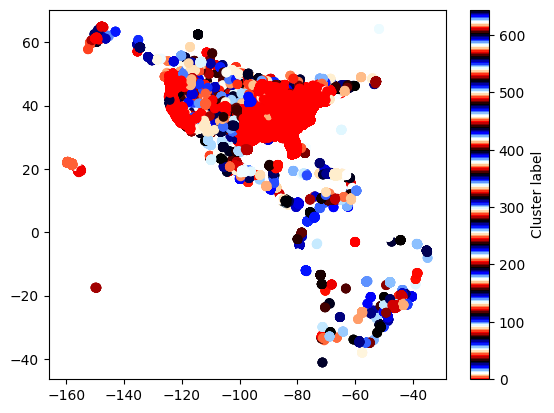

In [23]:
# Plot of NOT noise clusters
# Perhaps we should plot by smaller areas in this case.
scatter = plt.scatter(df_left_unique_id['longitude'][df_left_unique_id["final_labels"] != -1], 
                      df_left_unique_id['latitude'][df_left_unique_id["final_labels"] != -1], 
                      c=df_left_unique_id["final_labels"][df_left_unique_id["final_labels"] != -1], cmap="flag") # cmap="tab20b"

plt.colorbar(scatter, label='Cluster label')

x_limits = plt.gca().get_xlim()
y_limits = plt.gca().get_ylim()

(-46.44254713503501, 70.262983968335)

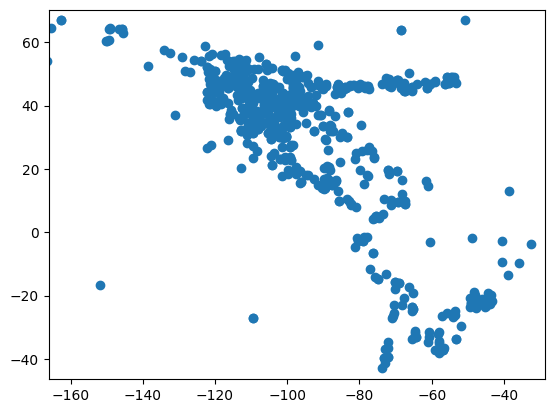

In [30]:
# Plotting noise:
lable_choice = -1  # label you want to plot

scatter = plt.scatter(df_left_unique_id['longitude'][df_left_unique_id["final_labels"] == lable_choice], 
                      df_left_unique_id['latitude'][df_left_unique_id["final_labels"] == lable_choice])
                    #c=df_left_unique_id["final_labels"][df_left_unique_id["final_labels"] == lable_choice]) # cmap="tab20b"

plt.xlim(x_limits)
plt.ylim(y_limits)

We still get a lot of clusters. Some of them seem sensible, for example, 0 and 1 as seen below. Yet there are lot of clusters that look as if they should be a single one, for example the black cluster at (-120, 40) that is surouned by a single red cluster (plotted below with label 1). More interestingly is the noise map: a lot of points that are noise look as if they were to falsely marked noise, as seen in the above noise plot.

(-46.44254713503501, 70.262983968335)

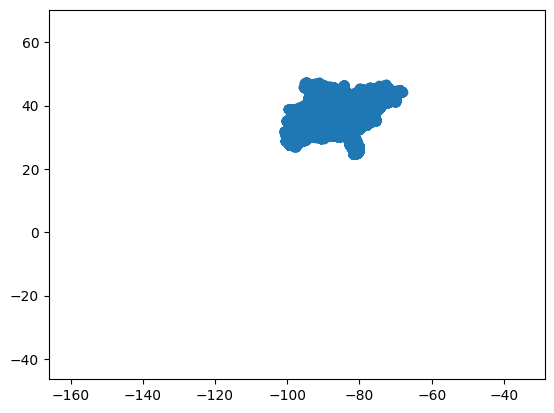

In [27]:
lable_choice = 0  # label you want to plot

scatter = plt.scatter(df_left_unique_id['longitude'][df_left_unique_id["final_labels"] == lable_choice], 
                      df_left_unique_id['latitude'][df_left_unique_id["final_labels"] == lable_choice])
                    #c=df_left_unique_id["final_labels"][df_left_unique_id["final_labels"] == lable_choice]) # cmap="tab20b"

plt.xlim(x_limits)
plt.ylim(y_limits)

(-46.44254713503501, 70.262983968335)

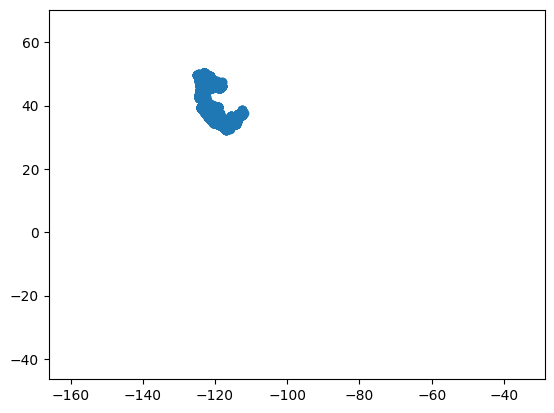

In [28]:
lable_choice = 1  # label you want to plot

scatter = plt.scatter(df_left_unique_id['longitude'][df_left_unique_id["final_labels"] == lable_choice], 
                      df_left_unique_id['latitude'][df_left_unique_id["final_labels"] == lable_choice])
                    #c=df_left_unique_id["final_labels"][df_left_unique_id["final_labels"] == lable_choice]) # cmap="tab20b"

plt.xlim(x_limits)
plt.ylim(y_limits)

Let's try with epsilon = 1. This time we'll need to split up the world into more pieces due to memmory limitations:

In [31]:
# We split the area into two with chosen epsilon
epsilon = 1

# Splitting the left side into two manageable reagions. The machine that ran the code could handle 160k points but not much more for this epsilon.
df_1 = df_left_unique_id[df_left_unique_id["longitude"] <= -120 + epsilon*1/2][["latitude", "longitude"]] 
df_2 = df_left_unique_id[(df_left_unique_id["longitude"] >= -120 - epsilon *1/2) & (df_left_unique_id["longitude"] <= -105 + epsilon *1/2)][["latitude", "longitude"]] 
df_3 = df_left_unique_id[(df_left_unique_id["longitude"] >= -105 - epsilon *1/2) & (df_left_unique_id["longitude"] <= -95 + epsilon *1/2)][["latitude", "longitude"]] 
df_4 = df_left_unique_id[(df_left_unique_id["longitude"] >= -95 - epsilon *1/2) & (df_left_unique_id["longitude"] <= -85 + epsilon *1/2)][["latitude", "longitude"]] 
df_5 = df_left_unique_id[(df_left_unique_id["longitude"] >= -85 - epsilon *1/2) & (df_left_unique_id["longitude"] <= -78 + epsilon *1/2)][["latitude", "longitude"]] 
df_6 = df_left_unique_id[(df_left_unique_id["longitude"] >= -78 - epsilon *1/2)][["latitude", "longitude"]] 

# We choose a smaller overalp to further decrease on points. Furthermoe epsilon 1 is a large radius.

print(len(df_1), "points in 1")
print(len(df_2), "points in 2")
print(len(df_3), "points in 3")
print(len(df_4), "points in 4")
print(len(df_5), "points in 5")
print(len(df_6), "points in 6")


102709 points in 1
110920 points in 2
140999 points in 3
132273 points in 4
140630 points in 5
135461 points in 6


In [ ]:
# Clustering and merging regions

In [32]:
labels_1, core_samples_1 = DBSCAN_clusterin(df_1, epsilon, min_points = 3)

21 clusters not incl noise
15 points of noise
0.01 % of data is noise


In [33]:
labels_2, core_samples_2 = DBSCAN_clusterin(df_2, epsilon, min_points = 3)

28 clusters not incl noise
14 points of noise
0.01 % of data is noise


In [34]:
push_2 = len(set(labels_1))
push_3 = len(set(labels_2)) + push_2
mappings, labels_right = create_mapping(df_1, labels_1, core_samples_1, df_2, labels_2, core_samples_2, push = push_2 )
new_1, new_2 = merge_labels(labels_1, labels_right, mappings)


4988  num of shared points


In [35]:
labels_3, core_samples_3 = DBSCAN_clusterin(df_3, epsilon, min_points = 3)

15 clusters not incl noise
15 points of noise
0.01 % of data is noise


In [36]:
mappings, labels_right = create_mapping(df_2, new_2, core_samples_2, df_3, labels_3, core_samples_3, push = push_3)
new_2, new_3 = merge_labels(new_2, labels_right, mappings)

10139  num of shared points


In [37]:
labels_4, core_samples_4 = DBSCAN_clusterin(df_4, epsilon, min_points = 3)

8 clusters not incl noise
6 points of noise
0.0 % of data is noise


In [38]:
push_4 =  len(set(labels_3)) + push_3
mappings, labels_right = create_mapping(df_3, new_3, core_samples_3, df_4, labels_4, core_samples_4, push = push_4)
new_3, new_4 = merge_labels(new_3, labels_right, mappings)

19589  num of shared points


In [39]:
labels_5, core_samples_5 = DBSCAN_clusterin(df_5, epsilon, min_points = 3)

13 clusters not incl noise
5 points of noise
0.0 % of data is noise


In [40]:
push_5 =  len(set(labels_4)) + push_4
mappings, labels_right = create_mapping(df_4, new_4, core_samples_4, df_5, labels_5, core_samples_5, push = push_5)
new_4, new_5 = merge_labels(new_4, labels_right, mappings)

10167  num of shared points


In [41]:
labels_6, core_samples_6 = DBSCAN_clusterin(df_6, epsilon, min_points = 3)

86 clusters not incl noise
49 points of noise
0.04 % of data is noise


In [42]:
push_6 =  len(set(labels_5)) + push_5
mappings, labels_right = create_mapping(df_5, new_5, core_samples_5, df_6, labels_6, core_samples_6, push = push_6)
new_5, new_6 = merge_labels(new_5, labels_right, mappings)

6008  num of shared points


In [43]:
# Merging into one label list. 

df_left_unique_id["final_labels"] = -1

df_1['labels'] = new_1
df_2['labels'] = new_2
df_3['labels'] = new_3
df_4['labels'] = new_4
df_5['labels'] = new_5
df_6['labels'] = new_6


# replace with new label if new label is not -1
df_left_unique_id.loc[df_1[df_1["labels"] != -1].index, "final_labels"] =  [x for x in new_1 if x != -1]
df_left_unique_id.loc[df_2[df_2["labels"] != -1].index, "final_labels"] = [x for x in new_2 if x != -1]
df_left_unique_id.loc[df_3[df_3["labels"] != -1].index, "final_labels"] = [x for x in new_3 if x != -1]
df_left_unique_id.loc[df_4[df_4["labels"] != -1].index, "final_labels"] = [x for x in new_4 if x != -1]
df_left_unique_id.loc[df_5[df_5["labels"] != -1].index, "final_labels"] = [x for x in new_5 if x != -1]
df_left_unique_id.loc[df_6[df_6["labels"] != -1].index, "final_labels"] = [x for x in new_6 if x != -1]

# Have to do it this way because indexes come from the orignal 6mln item data set. 

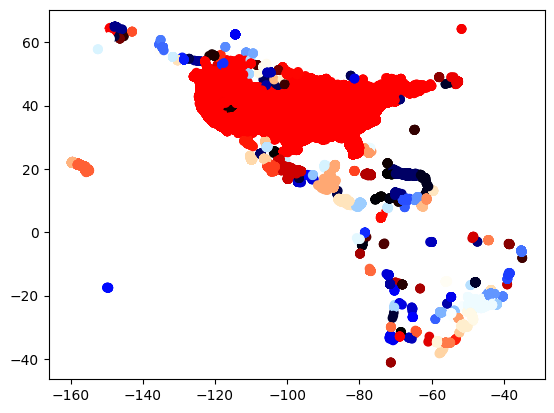

In [44]:
# Plot of NOT noise clusters
scatter = plt.scatter(df_left_unique_id['longitude'][df_left_unique_id["final_labels"] != -1], 
                      df_left_unique_id['latitude'][df_left_unique_id["final_labels"] != -1], 
                      c=df_left_unique_id["final_labels"][df_left_unique_id["final_labels"] != -1], cmap="flag", alpha = 1)

#plt.colorbar(scatter, label='Cluster label')

x_limits = plt.gca().get_xlim()
y_limits = plt.gca().get_ylim()

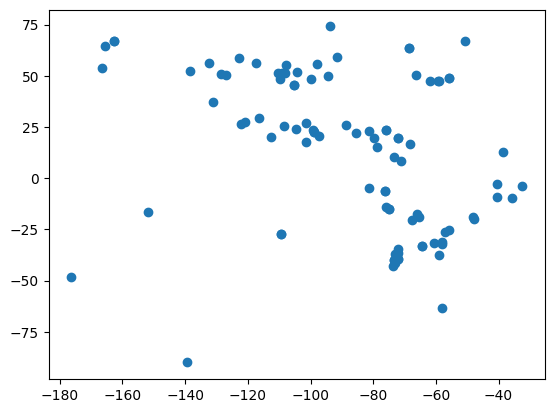

In [46]:
# Plotting noise:
lable_choice = -1  # label you want to plot

scatter = plt.scatter(df_left_unique_id['longitude'][df_left_unique_id["final_labels"] == lable_choice], 
                      df_left_unique_id['latitude'][df_left_unique_id["final_labels"] == lable_choice])
                    #c=df_left_unique_id["final_labels"][df_left_unique_id["final_labels"] == lable_choice]) # cmap="tab20b"

#plt.xlim(x_limits)
#plt.ylim(y_limits)

The noise plot seems to look more realistic yet we see in south america an noise clustering around (-75, -37) which looks almost like a cluster. Furthermore, USA is primarily one giant cluster which does not allow us to infer anything special. Thys clearly for USA epsilon = 1 is too large. Yet it seems cluster more sensibly for the caribbean area. Thus it is likely that due to the difference of distributions DBScan will give bad clustreing in at least one region for any chosen epsilon (for epsilon we get too much noise, for large - densne regions become a single uninfromative cluster). Furthermore in this case we have no heuristics as how to choose epsilon.

Furthermore, this gives ideas on what could work better for location clustering, for example, picking a method that does not require a single choice of epsilon. Another avenue is including the frequency of visits to a single place as an extra dimension. The idea behind this would be that even if we have 3 locations near to each other they are likely to be noise if they very few total visits. On the other hand a location with a lot of visits probably should not be marked as noise even if it is fairly isolated.
